In [ ]:
# System and path configuration
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Core LSD imports
from codes.lsd_train import LSD
from codes.utils import (
    plot_random_walks,
    cross_boundary_correctness,
    plot_z_components,
    visualize_random_walks_on_umap
)
from codes.config import LSDConfig
# Scientific computing
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Deep learning
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc
import scvelo as scv
import cellrank as cr
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean

# Configure matplotlib for better output
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['svg.fonttype'] = 'none'  # Use text instead of paths for fonts
sns.set_style('white')
sns.set_palette('husl')

print("Environment configured successfully!")

Environment configured successfully!


In [2]:
# Configure computational device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check GPU details if available
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda:1
GPU Name: NVIDIA GeForce RTX 3090
GPU Memory: 25.44 GB


## Section 2: Data Loading and Exploration

Load the preprocessed dentate gyrus dataset and explore its structure.

In [3]:
# Load preprocessed dentate gyrus data
# This dataset contains adult hippocampal neurogenesis cells
# Already normalized with:
# - Log-normalized gene expression in .X
# - Raw counts in .layers['raw']
# - Library sizes in .obs['librarysize']

data_path = "../../data/DentateGyrus/normalized_before_low.h5ad"
adata = sc.read(data_path)

print("Dataset loaded successfully!")
print(f"Data path: {data_path}")
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAvailable data layers: {list(adata.layers.keys())}")
print(f"Cell metadata columns: {list(adata.obs.columns)}")

# Display cell type distribution
print(f"\nCell type distribution:")
cluster_counts = adata.obs['clusters'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / adata.n_obs) * 100
    print(f"  {cluster}: {count:,} cells ({percentage:.1f}%)")

Dataset loaded successfully!
Data path: ../../data/DentateGyrus/normalized_before_low.h5ad
Number of cells: 2,460
Number of genes: 1,500

Available data layers: ['ambiguous', 'raw', 'spliced', 'unspliced']
Cell metadata columns: ['clusters', 'age(days)', 'clusters_enlarged', 'prior_pseudotime', 'librarysize']

Cell type distribution:
  Astrocytes: 120 cells (4.9%)
  Granule immature: 785 cells (31.9%)
  Granule mature: 1,068 cells (43.4%)
  Neuroblast: 417 cells (17.0%)
  Radial Glia-like: 51 cells (2.1%)
  nIPC: 19 cells (0.8%)


In [4]:
# Define the differentiation phylogeny for dentate gyrus neurogenesis
# This represents the known biological progression:
# - Neuronal lineage: nIPC → Neuroblast → Granule immature → Granule mature
# - Glial lineage: nIPC → Radial Glia-like → Astrocytes

phylogeny = {
    "nIPC":             ["Neuroblast", "Radial Glia-like"],  # Progenitor bifurcation
    "Neuroblast":       ["Granule immature"],                # Neuronal commitment
    "Granule immature": ["Granule mature"],                  # Neuronal maturation
    "Granule mature":   [],                                  # Terminal neuronal state
    "Radial Glia-like": ["Astrocytes"],                     # Glial differentiation
    "Astrocytes":       []                                   # Terminal glial state
}

print("Differentiation phylogeny defined:")
print("\nNeuronal lineage:")
print("  nIPC → Neuroblast → Granule immature → Granule mature")
print("\nGlial lineage:")
print("  nIPC → Radial Glia-like → Astrocytes")
print("\nBifurcation point: nIPC (neural intermediate progenitor cells)")

Differentiation phylogeny defined:

Neuronal lineage:
  nIPC → Neuroblast → Granule immature → Granule mature

Glial lineage:
  nIPC → Radial Glia-like → Astrocytes

Bifurcation point: nIPC (neural intermediate progenitor cells)


In [5]:
# Initialize the LSD model
print("Initializing LSD model for dentate gyrus neurogenesis...")
cfg = LSDConfig()
cfg.optimizer.adam.lr = 2e-3
cfg.walks.path_len = 12
cfg.walks.num_walks = 2048
# Set random seed before model initialization
pyro.set_rng_seed(42)

lsd = LSD(
    adata,                           # Single-cell data
    cfg,
    device=device,                   # Computation device
    lib_size_key="librarysize",      # Column name for library sizes
    raw_count_key="raw",             # Layer name for raw counts
)

print("Model initialized successfully!")
print(f"  Latent cell state dimension: {lsd.z_dim}")
print(f"  Differentiation state dimension: {lsd.B_dim}")
print(f"  Potential regularization: {lsd.lsd.V_coeff}")

Initializing LSD model for dentate gyrus neurogenesis...
Model initialized successfully!
  Latent cell state dimension: 10
  Differentiation state dimension: 2
  Potential regularization: 0.01


Setting phylogeny constraints for neurogenesis...

Setting prior transition matrix from pseudotime...
[LSD] Removing 3 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.

Biological constraints successfully incorporated

Random walks generated successfully!

Visualizing random walks on UMAP...


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


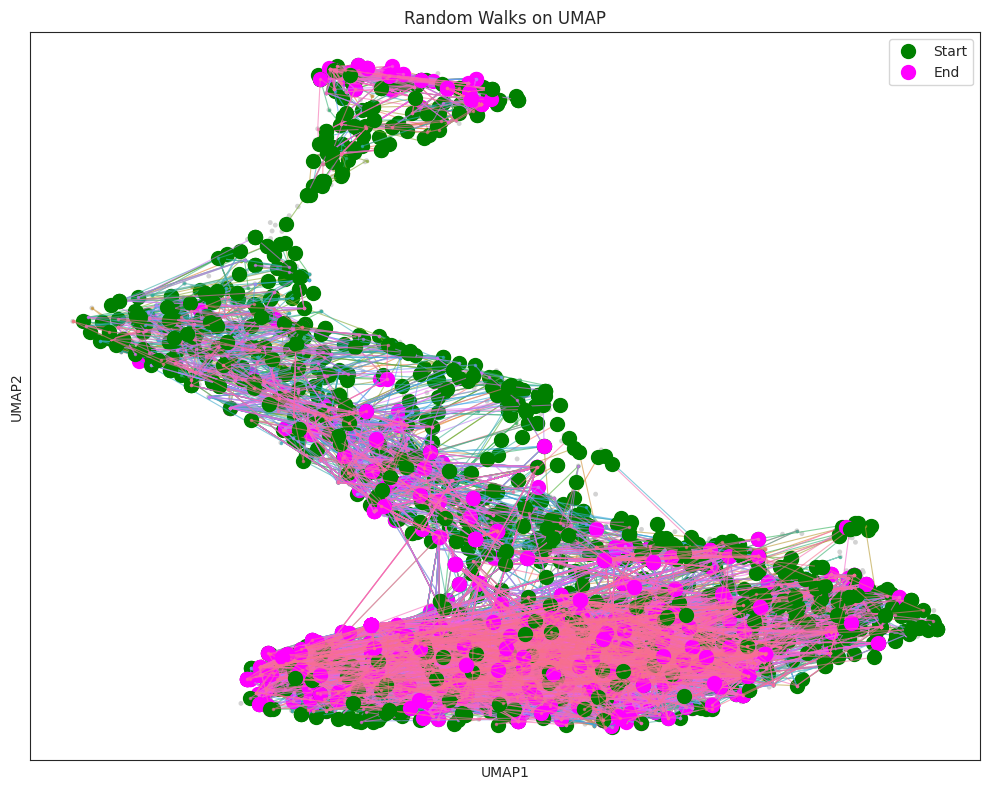

In [6]:
# Set phylogeny constraints and prior transitions
print("Setting phylogeny constraints for neurogenesis...")
lsd.set_phylogeny(phylogeny, cluster_key="clusters")

# Check if prior pseudotime is available
if "prior_pseudotime" in adata.obs.columns:
    print("\nSetting prior transition matrix from pseudotime...")
    lsd.set_prior_transition(prior_time_key="prior_pseudotime")
else:
    print("\nNo prior pseudotime found, using phylogeny only")

print("\nBiological constraints successfully incorporated")

lsd.prepare_walks()
print(f"\nRandom walks generated successfully!")
print("\nVisualizing random walks on UMAP...")
plot_random_walks(lsd.adata, lsd.walks, "X_umap")


Pyro parameter store cleared
Model checkpoints will be saved to: ../../DentateGyrus_model

Starting model training...
Training for 250 epochs
This may take 30-45 minutes depending on GPU



Training Epochs:   0%|          | 0/250 [00:00<?, ?it/s]

Training Epochs: 100%|██████████| 250/250 [16:42<00:00,  4.01s/it, -ELBO=0.4993, Potential Metric=0.0559, Entropy Metric=0.0508]


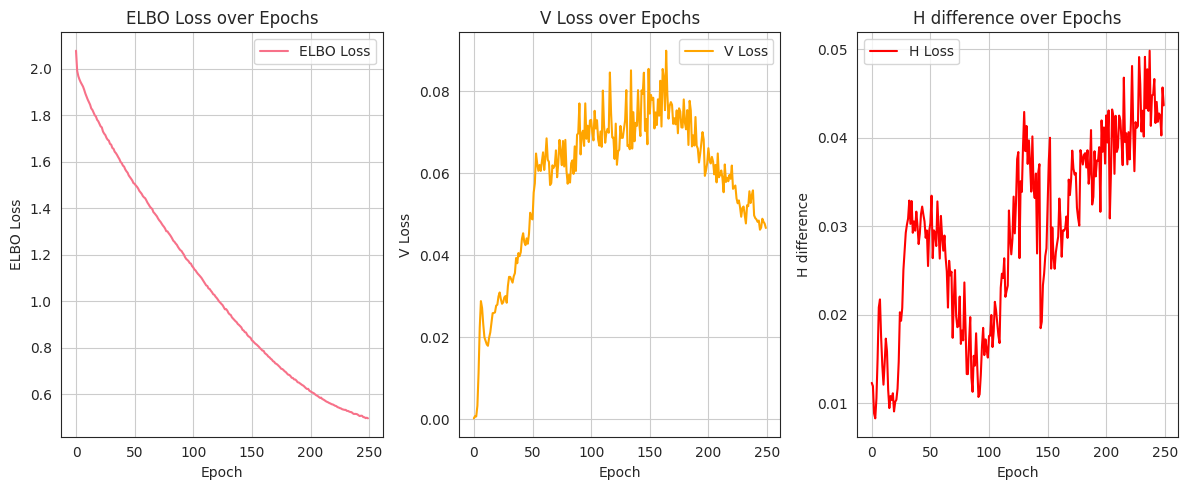


Training completed successfully!


In [7]:
# Clear any existing parameters
pyro.clear_param_store()
print("Pyro parameter store cleared")
num_epochs = 250
# Create save directory for model checkpoints
save_dir = "../../DentateGyrus_model"
os.makedirs(save_dir, exist_ok=True)
print(f"Model checkpoints will be saved to: {save_dir}")

print("\n" + "="*60)
print("Starting model training...")
print("="*60)
print(f"Training for {num_epochs} epochs")
print("This may take 30-45 minutes depending on GPU")
print("")

# Train the model
lsd.train(
    num_epochs=num_epochs,      # 250 epochs
    save_dir=save_dir,          # Directory for checkpoints
    save_interval=50,           # Save every 50 epochs
    random_state=42             # Random seed
)

print("\n" + "="*60)
print("Training completed successfully!")
print("="*60)